In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/adult.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.info()
df["income"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [5]:
df.nunique().sort_values()

income                2
sex                   2
race                  5
relationship          6
marital_status        7
workclass             8
occupation           14
education            16
education_num        16
native_country       41
age                  73
capital_loss         92
hours_per_week       94
capital_gain        119
fnlwgt            21648
dtype: int64

In [6]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(df[column].value_counts().head(10))


workclass:
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

education:
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
Name: count, dtype: int64

marital_status:
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

occupation:
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education_num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital_gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital_loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours_per_week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [8]:
df.nunique().sort_values()

income                2
sex                   2
race                  5
relationship          6
marital_status        7
workclass             8
occupation           14
education            16
education_num        16
native_country       41
age                  73
capital_loss         92
hours_per_week       94
capital_gain        119
fnlwgt            21648
dtype: int64

In [14]:
numeric_features = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]
categorical_features = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"
    
]

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("income", axis=1)
y = df["income"]

# Convert target into 0/1
y = y.map({
    "<=50K": 0,
    ">50K": 1
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 26048
Testing samples: 6513


In [16]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
income
0    0.759175
1    0.240825
Name: proportion, dtype: float64

Testing class distribution:
income
0    0.759251
1    0.240749
Name: proportion, dtype: float64


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [22]:
numeric_features = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

categorical_features = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"
]

In [23]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [25]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [26]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
y_pred = logistic_model.predict(X_test)

print(y_pred[:20])

[0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0]


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8558268079226163
Precision: 0.740627390971691
Recall   : 0.6173469387755102
F1 Score : 0.6733913043478261


In [29]:
y_probability = logistic_model.predict_proba(X_test)[:, 1]

print("ROC-AUC  :", roc_auc_score(y_test, y_probability))

ROC-AUC  : 0.9078006025463776


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4945
           1       0.74      0.62      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513



In [31]:
from sklearn.ensemble import RandomForestClassifier

numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numeric_features),
        ("cat", categorical_transformer_rf, categorical_features)
    ]
)

In [32]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [33]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
rf_pred = random_forest_model.predict(X_test)
rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

In [35]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_probability))

Accuracy : 0.8578228159066482
Precision: 0.7353372434017595
Recall   : 0.6396683673469388
F1 Score : 0.6841746248294679
ROC-AUC  : 0.908437519345453


In [36]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4945
           1       0.74      0.64      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.80      6513
weighted avg       0.85      0.86      0.85      6513



In [37]:
results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, rf_pred),
        "Precision": precision_score(y_test, rf_pred),
        "Recall": recall_score(y_test, rf_pred),
        "F1": f1_score(y_test, rf_pred),
        "ROC-AUC": roc_auc_score(y_test, rf_probability)
    }
}

results_df = pd.DataFrame(results).T
results_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8558,0.7406,0.6173,0.6734,0.9078
Random Forest,0.8578,0.7353,0.6397,0.6842,0.9084


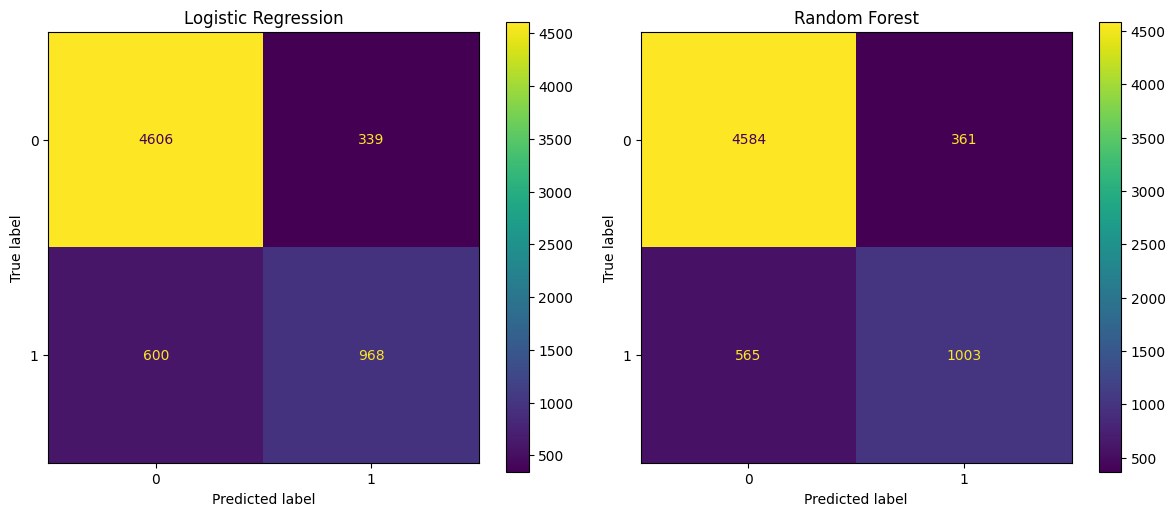

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    ax=axes[1]
)

axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

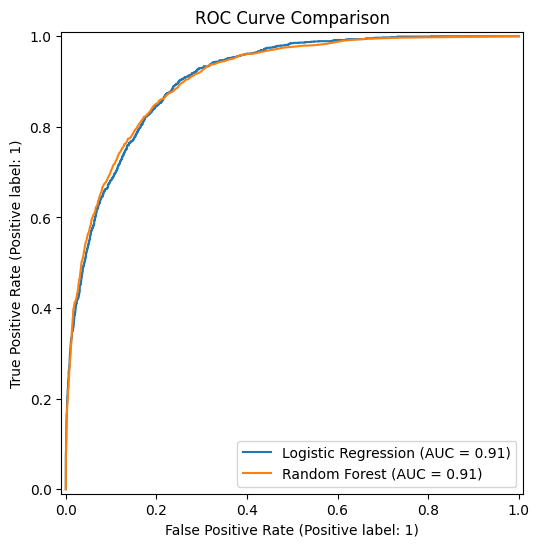

In [39]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_probability,
    name="Random Forest",
    ax=ax
)

ax.set_title("ROC Curve Comparison")
plt.show()

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    lr_predictions = (y_probability >= threshold).astype(int)
    rf_predictions = (rf_probability >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "LR Precision": precision_score(y_test, lr_predictions),
        "LR Recall": recall_score(y_test, lr_predictions),
        "LR F1": f1_score(y_test, lr_predictions),
        "RF Precision": precision_score(y_test, rf_predictions),
        "RF Recall": recall_score(y_test, rf_predictions),
        "RF F1": f1_score(y_test, rf_predictions),
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,LR Precision,LR Recall,LR F1,RF Precision,RF Recall,RF F1
0,0.3,0.6062,0.8010,0.6901,0.6090,0.8106,0.6955
1,0.4,0.6735,0.6920,0.6826,0.6716,0.7302,0.6997
2,0.5,0.7406,0.6173,0.6734,0.7345,0.6441,0.6864
3,0.6,0.7880,0.5121,0.6208,0.7916,0.5523,0.6506
4,0.7,0.8503,0.4056,0.5492,0.8365,0.4534,0.5881


In [41]:
from sklearn.model_selection import train_test_split

X_train_new, X_temp, y_train_new, y_temp = train_test_split(
    X,
    y,
    test_size=0.36,
    random_state=42,
    stratify=y
)

X_val, X_test_new, y_val, y_test_new = train_test_split(
    X_temp,
    y_temp,
    test_size=(0.20 / 0.36),
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train_new.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_new.shape)

Training: (20839, 14)
Validation: (5209, 14)
Test: (6513, 14)


## Experiment 2 — Validation-Based Threshold Selection

#The original experiment used a default classification threshold of 0.5.
#Here, we introduce a validation set so that the classification threshold can
#be selected without using the final test set.

In [43]:
# Train Logistic Regression on the training set only
logistic_model_val = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model_val.fit(X_train_new, y_train_new)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
# Train Random Forest on the training set only
random_forest_model_val = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model_val.fit(X_train_new, y_train_new)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
lr_val_probability = logistic_model_val.predict_proba(X_val)[:, 1]
rf_val_probability = random_forest_model_val.predict_proba(X_val)[:, 1]


In [46]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

validation_results = []

for threshold in thresholds:

    lr_pred = (lr_val_probability >= threshold).astype(int)
    rf_pred = (rf_val_probability >= threshold).astype(int)

    validation_results.append({
        "Threshold": threshold,

        "LR Precision": precision_score(y_val, lr_pred),
        "LR Recall": recall_score(y_val, lr_pred),
        "LR F1": f1_score(y_val, lr_pred),

        "RF Precision": precision_score(y_val, rf_pred),
        "RF Recall": recall_score(y_val, rf_pred),
        "RF F1": f1_score(y_val, rf_pred)
    })

validation_df = pd.DataFrame(validation_results)


validation_df.round(4)

,Threshold,LR Precision,LR Recall,LR F1,RF Precision,RF Recall,RF F1
0,0.30,0.5986,0.7943,0.6827,0.6006,0.8118,0.6904
1,0.35,0.6433,0.7392,0.6879,0.6305,0.7687,0.6928
2,0.40,0.6809,0.6890,0.6849,0.6733,0.7249,0.6982
3,0.45,0.7057,0.6483,0.6758,0.7007,0.6834,0.6920
4,0.50,0.7343,0.6061,0.6640,0.7356,0.6324,0.6801
5,0.55,0.7593,0.5510,0.6386,0.7603,0.5869,0.6625
6,0.60,0.7873,0.4960,0.6086,0.7825,0.5423,0.6406
7,0.65,0.8179,0.4514,0.5817,0.8005,0.4960,0.6125
8,0.70,0.8478,0.3907,0.5349,0.8412,0.4522,0.5882


In [47]:
best_lr = validation_df.loc[
    validation_df["LR F1"].idxmax()
]

best_rf = validation_df.loc[
    validation_df["RF F1"].idxmax()
]

print("Best Logistic Regression threshold:")
print(best_lr)

print("\nBest Random Forest threshold:")
print(best_rf)

Best Logistic Regression threshold:
Threshold       0.350000
LR Precision    0.643303
LR Recall       0.739234
LR F1           0.687941
RF Precision    0.630477
RF Recall       0.768740
RF F1           0.692778
Name: 1, dtype: float64

Best Random Forest threshold:
Threshold       0.400000
LR Precision    0.680851
LR Recall       0.688995
LR F1           0.684899
RF Precision    0.673333
RF Recall       0.724880
RF F1           0.698157
Name: 2, dtype: float64


## Final Evaluation on the Held-Out Test Set

The validation set was used to select the classification threshold.
The final test set was not used during model selection.

The selected thresholds are:
- Logistic Regression: 0.35
- Random Forest: 0.40

In [48]:
# Get probabilities on the untouched test set

lr_test_probability = logistic_model_val.predict_proba(X_test_new)[:, 1]
rf_test_probability = random_forest_model_val.predict_proba(X_test_new)[:, 1]

In [50]:
LR_THRESHOLD = 0.35
RF_THRESHOLD = 0.40

lr_test_pred = (lr_test_probability >= LR_THRESHOLD).astype(int)
rf_test_pred = (rf_test_probability >= RF_THRESHOLD).astype(int)

In [51]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Threshold": [
        LR_THRESHOLD,
        RF_THRESHOLD
    ],
    "Accuracy": [
        accuracy_score(y_test_new, lr_test_pred),
        accuracy_score(y_test_new, rf_test_pred)
    ],
    "Precision": [
        precision_score(y_test_new, lr_test_pred),
        precision_score(y_test_new, rf_test_pred)
    ],
    "Recall": [
        recall_score(y_test_new, lr_test_pred),
        recall_score(y_test_new, rf_test_pred)
    ],
    "F1": [
        f1_score(y_test_new, lr_test_pred),
        f1_score(y_test_new, rf_test_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_new, lr_test_probability),
        roc_auc_score(y_test_new, rf_test_probability)
    ]
})

final_results.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.35,0.8403,0.6461,0.7457,0.6923,0.9063
1,Random Forest,0.40,0.8489,0.6744,0.7208,0.6969,0.9020


In [52]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Threshold": [
        LR_THRESHOLD,
        RF_THRESHOLD
    ],
    "Accuracy": [
        accuracy_score(y_test_new, lr_test_pred),
        accuracy_score(y_test_new, rf_test_pred)
    ],
    "Precision": [
        precision_score(y_test_new, lr_test_pred),
        precision_score(y_test_new, rf_test_pred)
    ],
    "Recall": [
        recall_score(y_test_new, lr_test_pred),
        recall_score(y_test_new, rf_test_pred)
    ],
    "F1": [
        f1_score(y_test_new, lr_test_pred),
        f1_score(y_test_new, rf_test_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_new, lr_test_probability),
        roc_auc_score(y_test_new, rf_test_probability)
    ]
})

final_results.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.35,0.8403,0.6461,0.7457,0.6923,0.9063
1,Random Forest,0.40,0.8489,0.6744,0.7208,0.6969,0.9020


In [53]:
print("Logistic Regression")
print(classification_report(y_test_new, lr_test_pred))

print("\nRandom Forest")
print(classification_report(y_test_new, rf_test_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      4944
           1       0.65      0.75      0.69      1569

    accuracy                           0.84      6513
   macro avg       0.78      0.81      0.79      6513
weighted avg       0.85      0.84      0.84      6513


Random Forest
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4944
           1       0.67      0.72      0.70      1569

    accuracy                           0.85      6513
   macro avg       0.79      0.81      0.80      6513
weighted avg       0.85      0.85      0.85      6513



In [54]:
final_results.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.35,0.8403,0.6461,0.7457,0.6923,0.9063
1,Random Forest,0.40,0.8489,0.6744,0.7208,0.6969,0.9020


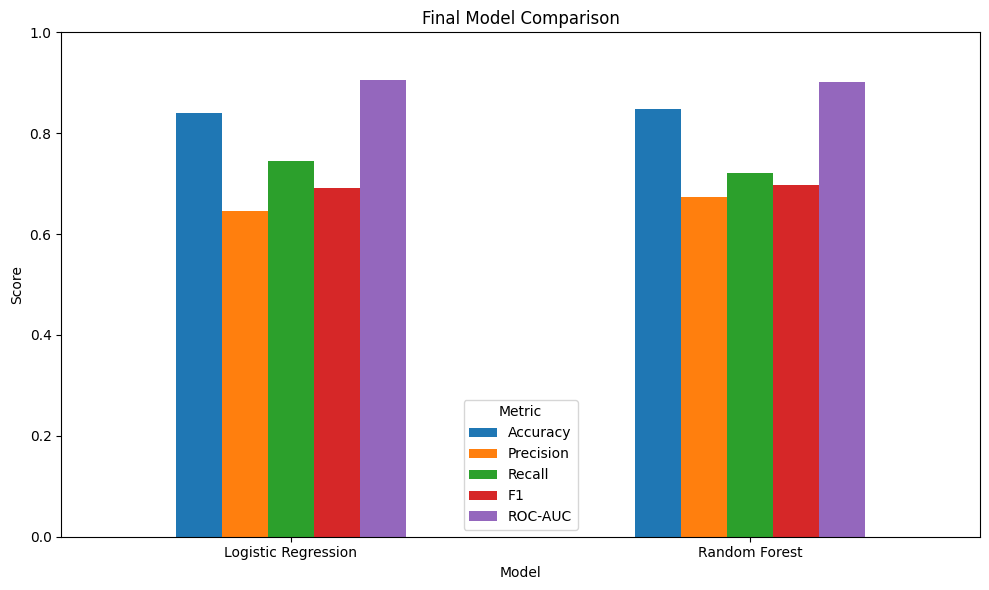

In [55]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

comparison = final_results.set_index("Model")[metrics]

ax = comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Final Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Metric")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

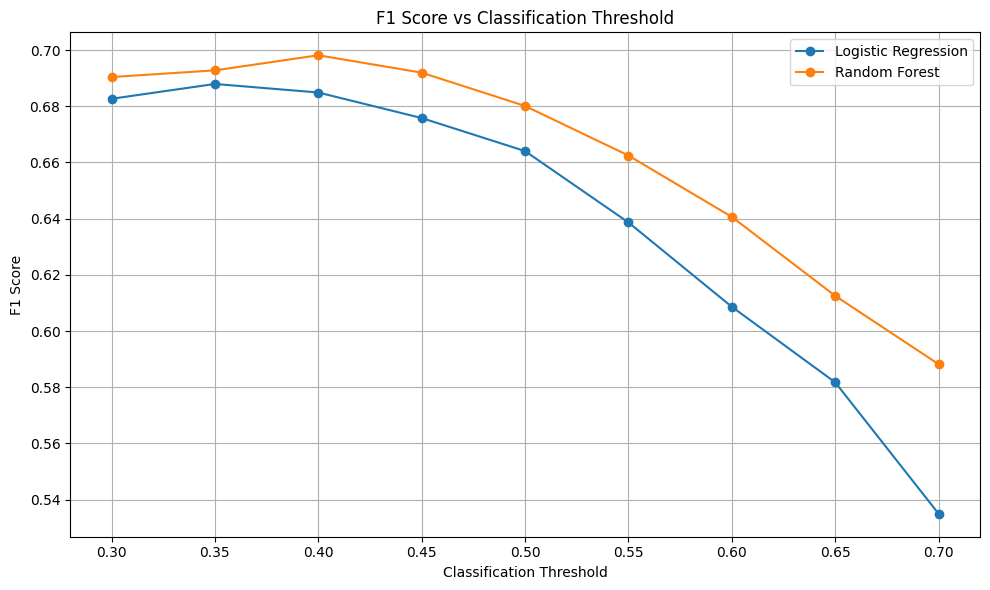

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    validation_df["Threshold"],
    validation_df["LR F1"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    validation_df["Threshold"],
    validation_df["RF F1"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

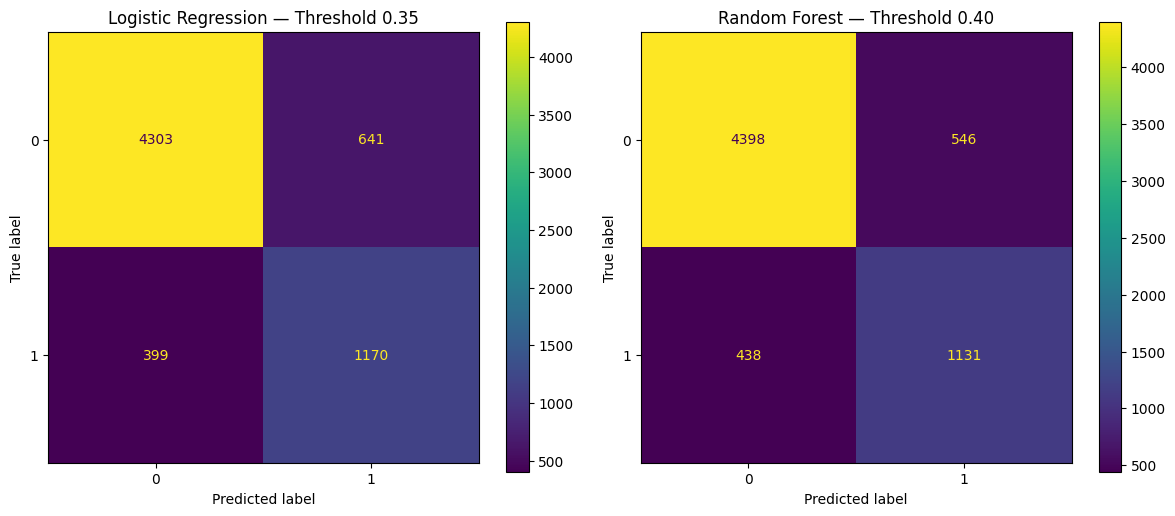

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_new,
    lr_test_pred,
    ax=axes[0]
)

axes[0].set_title("Logistic Regression — Threshold 0.35")

ConfusionMatrixDisplay.from_predictions(
    y_test_new,
    rf_test_pred,
    ax=axes[1]
)

axes[1].set_title("Random Forest — Threshold 0.40")

plt.tight_layout()
plt.show()

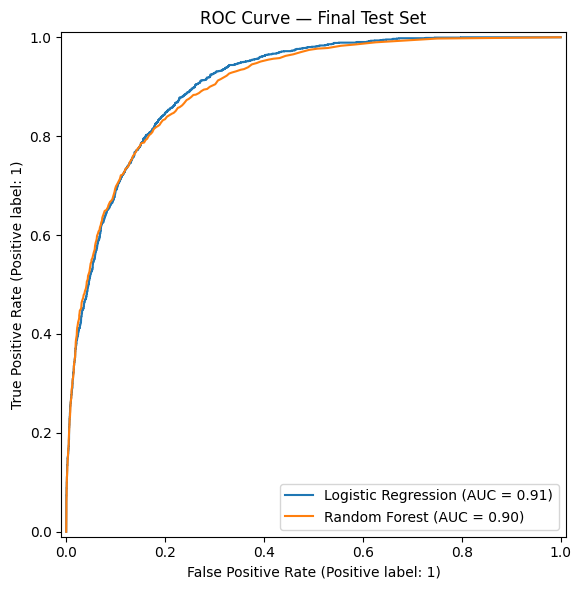

In [58]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test_new,
    lr_test_probability,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test_new,
    rf_test_probability,
    name="Random Forest",
    ax=ax
)

ax.set_title("ROC Curve — Final Test Set")

plt.tight_layout()
plt.show()